In [6]:
from TeamParam import TeamParam
from GameParams import GameParams
import numpy as np
import matplotlib.pyplot as plt
import numpy as np



In [ ]:
P_discrete = [
    (7.0, 0.35),   # short reset/dump
    (12.0, 0.30),  # short gain
    (20.0, 0.20),  # medium progression
    (35.0, 0.10),  # long throw
    (50.0, 0.05),  # deep shot
]
def short_throw_T(d: float, dmax: float) -> float:
    return 0.95  # very high completion for resets/dumps

def mid_throw_T(d: float, dmax: float) -> float:
    return 0.85  # moderate risk

def long_throw_T(d: float, dmax: float) -> float:
    return 0.65  # deep shots are risky

T_list = [
    0.98,
    0.95,
    0.85,
    0.75,
    0.70,
    0.60,
    0.50,
]

team_a = TeamParam(
    P=P_discrete,
    T=T_list,
    attack_sign=1,
)
team_b = TeamParam(
    P=P_discrete,
    T=T_list,
    attack_sign=-1,
)

game_params = GameParams()

rng = np.random.default_rng()
team_a_score = 0
team_b_score = 0
max_plays = 100_000

offense = team_a

## Visualization: strategy difference

**Strategy** here means the discrete **mix** `P`: how often each throw distance is attempted. **`T_list`** gives the completion chance for each bucket (short vs long risk). The **balanced** curve is the notebook’s `P_discrete`. The **aggressive** curve keeps the same distances and `T_list` but shifts probability toward longer throws—usually lowering the **per-throw** completion rate on average because long buckets are riskier.

In [10]:
for _ in range(100_000):
    if offense is team_a:
        x = float(rng.uniform(0.6*game_params.D_full, game_params.D_full))
    else:   
        x = float(rng.uniform(0,0.4*game_params.D_full))
    print(f"Starting new play with initial position {x:.2f}")

    for _ in range(max_plays):
        d, complete = offense.sample_throw(x, game_params, rng)
        x = game_params.position_after_throw(x, d, offense.attack_sign)
        print(f"Offense: {'A' if offense is team_a else 'B'}, Throw distance: {d:.2f}, New position: {x:.2f}, Complete: {complete}")
        if complete:
            if offense is team_a and game_params.in_E_A(x):
                team_a_score += 1
                break
            if offense is team_b and game_params.in_E_B(x):
                team_b_score += 1
                break
        else:
            offense = team_b if offense is team_a else team_a

print(f"Team A wins: {team_a_score}")
print(f"Team B wins: {team_b_score}")


Starting new play with initial position 69.14


TypeError: 'list' object is not callable

In [8]:
P_discrete = [
    (-10, 4),   # backhand reset
    (-1.0, 9),
    (7.0, 26),  # short reset/dump
    (12.0, 30), # short gain
    (20.0, 17), # medium progression
    (35.0, 9),  # long throw
    (50.0, 5),  # deep shot
]  # total = 100

P_aggressive = [
    (-10, 3),   # backhand reset
    (-1.0, 7),
    (7.0, 10),
    (12.0, 15),
    (20.0, 17),
    (35.0, 26),
    (50.0, 22),
]  # total = 100

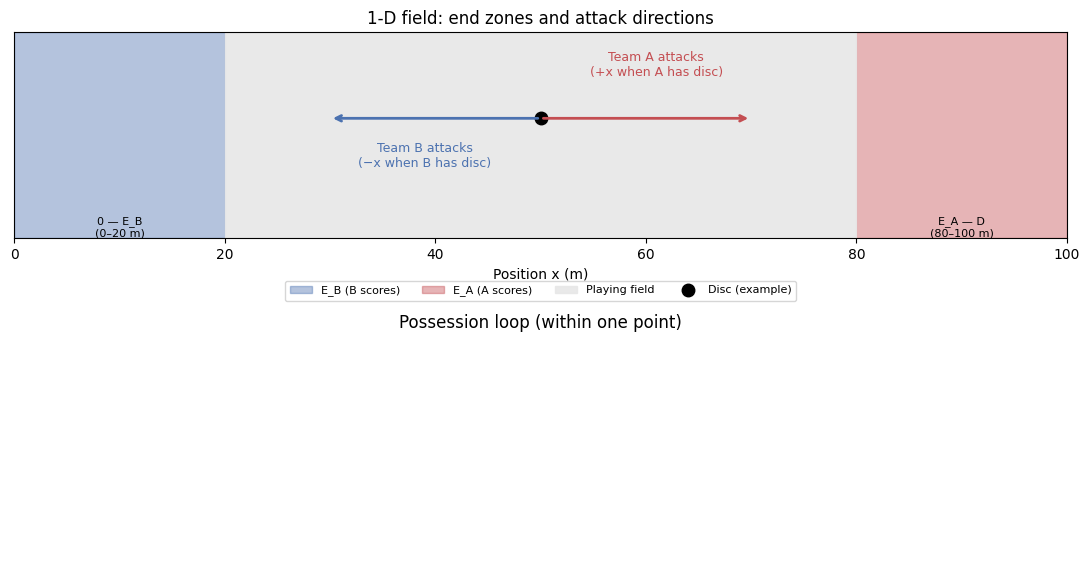

In [9]:
from matplotlib.patches import FancyArrowPatch


def plot_game_procedure(gp: GameParams) -> None:
    fig, (ax_field, ax_flow) = plt.subplots(
        2,
        1,
        figsize=(11, 5.8),
        gridspec_kw={"height_ratios": [1.15, 1.25]},
    )
    D = gp.D_full
    mid = 0.5 * (gp.E_B_hi + gp.E_A_lo)

    ax_field.set_xlim(0, D)
    ax_field.set_ylim(-0.22, 1.05)
    ax_field.set_title("1-D field: end zones and attack directions")
    ax_field.set_yticks([])
    ax_field.set_xlabel("Position x (m)")

    ax_field.axvspan(0, gp.E_B_hi, color="#4C72B0", alpha=0.42, label="E_B (B scores)")
    ax_field.axvspan(gp.E_A_lo, D, color="#C44E52", alpha=0.42, label="E_A (A scores)")
    ax_field.axvspan(gp.E_B_hi, gp.E_A_lo, color="#E8E8E8", alpha=0.92, label="Playing field")

    ax_field.plot([mid], [0.52], "o", color="black", ms=9, label="Disc (example)")
    ax_field.annotate(
        "",
        xy=(min(mid + 20, gp.E_A_lo - 4), 0.52),
        xytext=(mid, 0.52),
        arrowprops=dict(arrowstyle="->", color="#C44E52", lw=2),
    )
    ax_field.text(
        mid + 11,
        0.78,
        "Team A attacks\n(+x when A has disc)",
        ha="center",
        fontsize=9,
        color="#C44E52",
    )
    ax_field.annotate(
        "",
        xy=(max(mid - 20, gp.E_B_hi + 4), 0.52),
        xytext=(mid, 0.52),
        arrowprops=dict(arrowstyle="->", color="#4C72B0", lw=2),
    )
    ax_field.text(
        mid - 11,
        0.22,
        "Team B attacks\n(−x when B has disc)",
        ha="center",
        fontsize=9,
        color="#4C72B0",
    )

    ax_field.text(
        gp.E_B_hi / 2,
        -0.08,
        f"0 — E_B\n({gp.E_B_lo:.0f}–{gp.E_B_hi:.0f} m)",
        ha="center",
        va="top",
        fontsize=8,
    )
    ax_field.text(
        (gp.E_A_lo + D) / 2,
        -0.08,
        f"E_A — D\n({gp.E_A_lo:.0f}–{D:.0f} m)",
        ha="center",
        va="top",
        fontsize=8,
    )
    ax_field.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=8)

    ax_flow.axis("off")
    ax_flow.set_xlim(0, 1)
    ax_flow.set_ylim(0, 1)
    ax_flow.set_title("Possession loop (within one point)")

    def box(xy, text):
        ax_flow.text(
            xy[0],
            xy[1],
            text,
            ha="center",
            va="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#333"),
        )

    def arr(p1, p2):
        ax_flow.add_patch(
            FancyArrowPatch(
                p1, p2, arrowstyle="-|>", mutation_scale=11, color="#333", lw=1.1
            )
        )

    # box((0.5, 0.9), "Start play:\ndraw initial x")
    # box((0.5, 0.68), "Sample throw distance\nd ~ discrete P")
    # box((0.5, 0.46), "Complete?\nBernoulli(T for that bucket)")
    # box((0.22, 0.22), "Yes:\nupdate x along\nattack sign")
    # box((0.78, 0.22), "No:\nturnover\n(same x, swap offense)")
    # box((0.5, 0.04), "If x in own end zone\nafter complete → score;\nelse next throw")

    # arr((0.5, 0.84), (0.5, 0.76))
    # arr((0.5, 0.62), (0.5, 0.54))
    # arr((0.43, 0.40), (0.30, 0.28))
    # arr((0.57, 0.40), (0.70, 0.28))
    # arr((0.26, 0.16), (0.42, 0.09))
    # arr((0.74, 0.16), (0.58, 0.09))

    plt.tight_layout()
    plt.show()


plot_game_procedure(game_params)

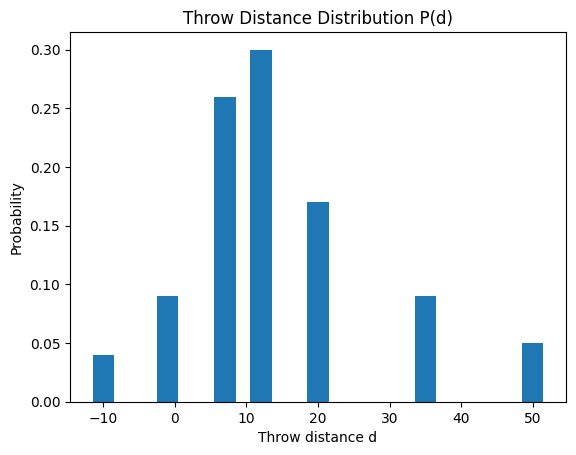

In [10]:
distances = np.array([d for d, _ in P_discrete])
weights = np.array([w for _, w in P_discrete])
probs = weights / weights.sum()

plt.figure()
plt.bar(distances, probs, width=3)
plt.xlabel("Throw distance d")
plt.ylabel("Probability")
plt.title("Throw Distance Distribution P(d)")
plt.show()

In [11]:
def discrete_probs(P):
    w = np.array([b for _, b in P], dtype=float)
    return w / w.sum()


def per_bucket_completion(P, T_fns, gp: GameParams):
    dists = np.array([d for d, _ in P], dtype=float)
    t = np.array([float(T_fns[i](dists[i], gp.d_max)) for i in range(len(P))])
    return dists, t


d_common, t_bucket = per_bucket_completion(P_discrete, T_list, game_params)
p_bal = discrete_probs(P_discrete)
p_agg = discrete_probs(P_aggressive)
exp_complete_bal = float(np.sum(p_bal * t_bucket))
exp_complete_agg = float(np.sum(p_agg * t_bucket))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

x = np.arange(len(d_common))
w = 0.36
axes[0].bar(x - w / 2, p_bal, w, label="balanced (P_discrete)", color="#4C72B0")
axes[0].bar(x + w / 2, p_agg, w, label="aggressive (longer bias)", color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{d:.0f} m" for d in d_common])
axes[0].set_ylabel("P(attempt this distance)")
axes[0].set_title("Throw mix: two strategies, same buckets")
axes[0].legend(fontsize=8)

x2 = np.arange(2)
axes[1].bar(
    x2 - 0.2,
    [exp_complete_bal, exp_complete_agg],
    0.4,
    label="P(complete) per throw",
    color="#55A868",
)
axes[1].bar(
    x2 + 0.2,
    [1.0 - exp_complete_bal, 1.0 - exp_complete_agg],
    0.4,
    label="P(turnover) per throw",
    color="#C44E52",
)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(["balanced mix", "aggressive mix"])
axes[1].set_ylabel("Probability")
axes[1].set_title("Marginal outcome per random throw (same T per bucket)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

IndexError: list index out of range